####1. IMPORT LIBRARY

In [2]:
#!pip install tensorflow

In [1]:
# --- Data Manipulation ---
import pandas as pd
import numpy as np
import re
import random
import os

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns


# --- Machine Learning & Preprocessing ---
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import MinMaxScaler
from lightgbm import LGBMRegressor

# --- Utilities ---
import warnings
warnings.filterwarnings('ignore') # Ignore warning messages for cleaner output

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

####SEED

*🔢 What is a Seed?*
A seed is a fixed input value that initializes a pseudo-random number generator (PRNG). Random number generators in Python (like numpy, random, TensorFlow, etc.) don’t produce truly random numbers — they produce pseudo-random numbers. If you give them the same seed, they will produce the same sequence of "random" numbers every time.SEED



What is a Seed?
A seed is an initial value that controls the sequence of numbers generated by a random number generator (RNG).
In machine learning, randomness is everywhere:

1. Splitting datasets (train/test)

2. Shuffling data

3. Weight initialization in neural networks

4. Random sampling (e.g., dropout)

__If you don’t fix a seed:__

*Every run may give slightly different results (accuracy, loss, etc.)*

__If you fix a seed:__

*You get the same random numbers every time → reproducible results.*


In [4]:
import numpy as np

np.random.seed(42)  # setting the seed
print(np.random.rand(3))

[0.37454012 0.95071431 0.73199394]


In [5]:
# Set seeds
SEED = 28

# NumPy random seed (used in ML operations like dataset shuffling, random splits, etc.)
np.random.seed(SEED)

# TensorFlow seed (controls randomness in TensorFlow operations)
tf.random.set_seed(SEED)

# Python's built-in random module seed (used in Python random functions)
random.seed(SEED)

# Python hash seed (ensures deterministic hashing for Python objects)
os.environ['PYTHONHASHSEED'] = str(SEED)

####2. Data Loading¶
Here, we load the training and test datasets from the provided CSV files. We'll create copies to ensure the original dataframes remain untouched.

In [6]:
# Load the datasets from CSV files
from google.colab import drive
drive.mount('/content/drive')
!cp /content/drive/MyDrive/Data_set/titanic_kaggle/train.csv /content/
df_train_raw = pd.read_csv("train.csv")

!cp /content/drive/MyDrive/Data_set/titanic_kaggle/test.csv /content/
df_test_raw = pd.read_csv("test.csv")

Mounted at /content/drive


In [7]:
#df_train_raw = pd.read_csv('../input/titanic/train.csv')
#df_test_raw = pd.read_csv('../input/titanic/test.csv')

# Create copies for manipulation
dftrain = df_train_raw.copy()
dftest = df_test_raw.copy()

In [8]:
dftrain.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
dftest.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
dftest.shape

(418, 11)

In [11]:
dftrain.shape

(891, 12)

In [12]:
dftrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [13]:
dftest.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [14]:
dftest.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1
Cabin,327


In [15]:
dftrain.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [16]:
dftrain.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


#### 3. Exploratory Data Analysis (EDA)¶
Now, let's visualize the data to uncover insights and relationships between features and the survival outcome.



#####3.1. Distribution of Survival
First, we'll see the distribution of our target variable, Survived. (0 = Did not survive, 1 = Survived).

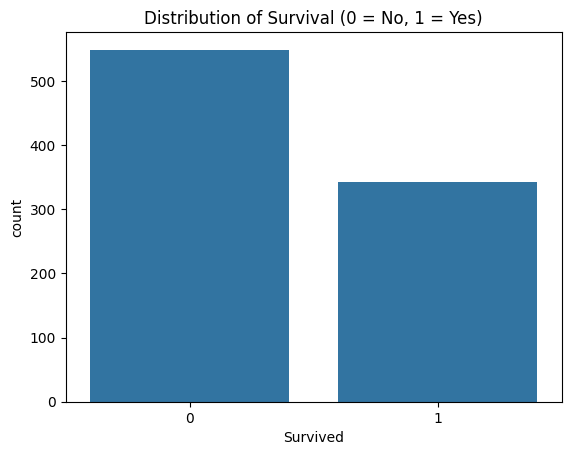

In [17]:
# Plot the distribution of the 'Survived' column
sns.countplot(x='Survived', data=dftrain)
plt.title('Distribution of Survival (0 = No, 1 = Yes)')
plt.show()

#####3.2. Age Distribution
Next, let's look at the age distribution of the passengers. This will be helpful before we decide on a strategy for imputing missing ages

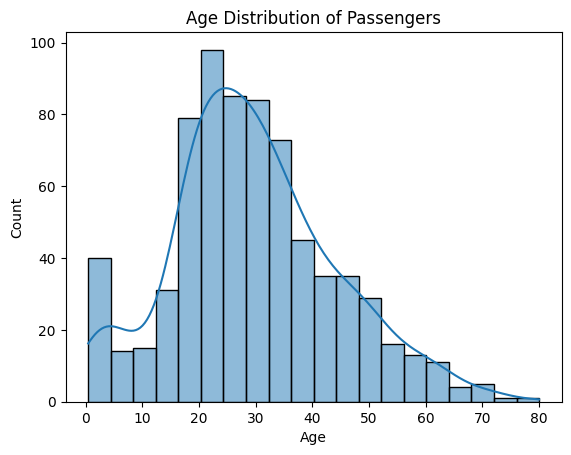

In [18]:
# Plot the distribution of passenger ages
sns.histplot(dftrain.Age.dropna(), kde=True)
plt.title('Age Distribution of Passengers')
plt.show()

#####3.3. Counts of Categorical Features
Here, we'll visualize the counts for key categorical features to understand their composition.

In [19]:
dftrain.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

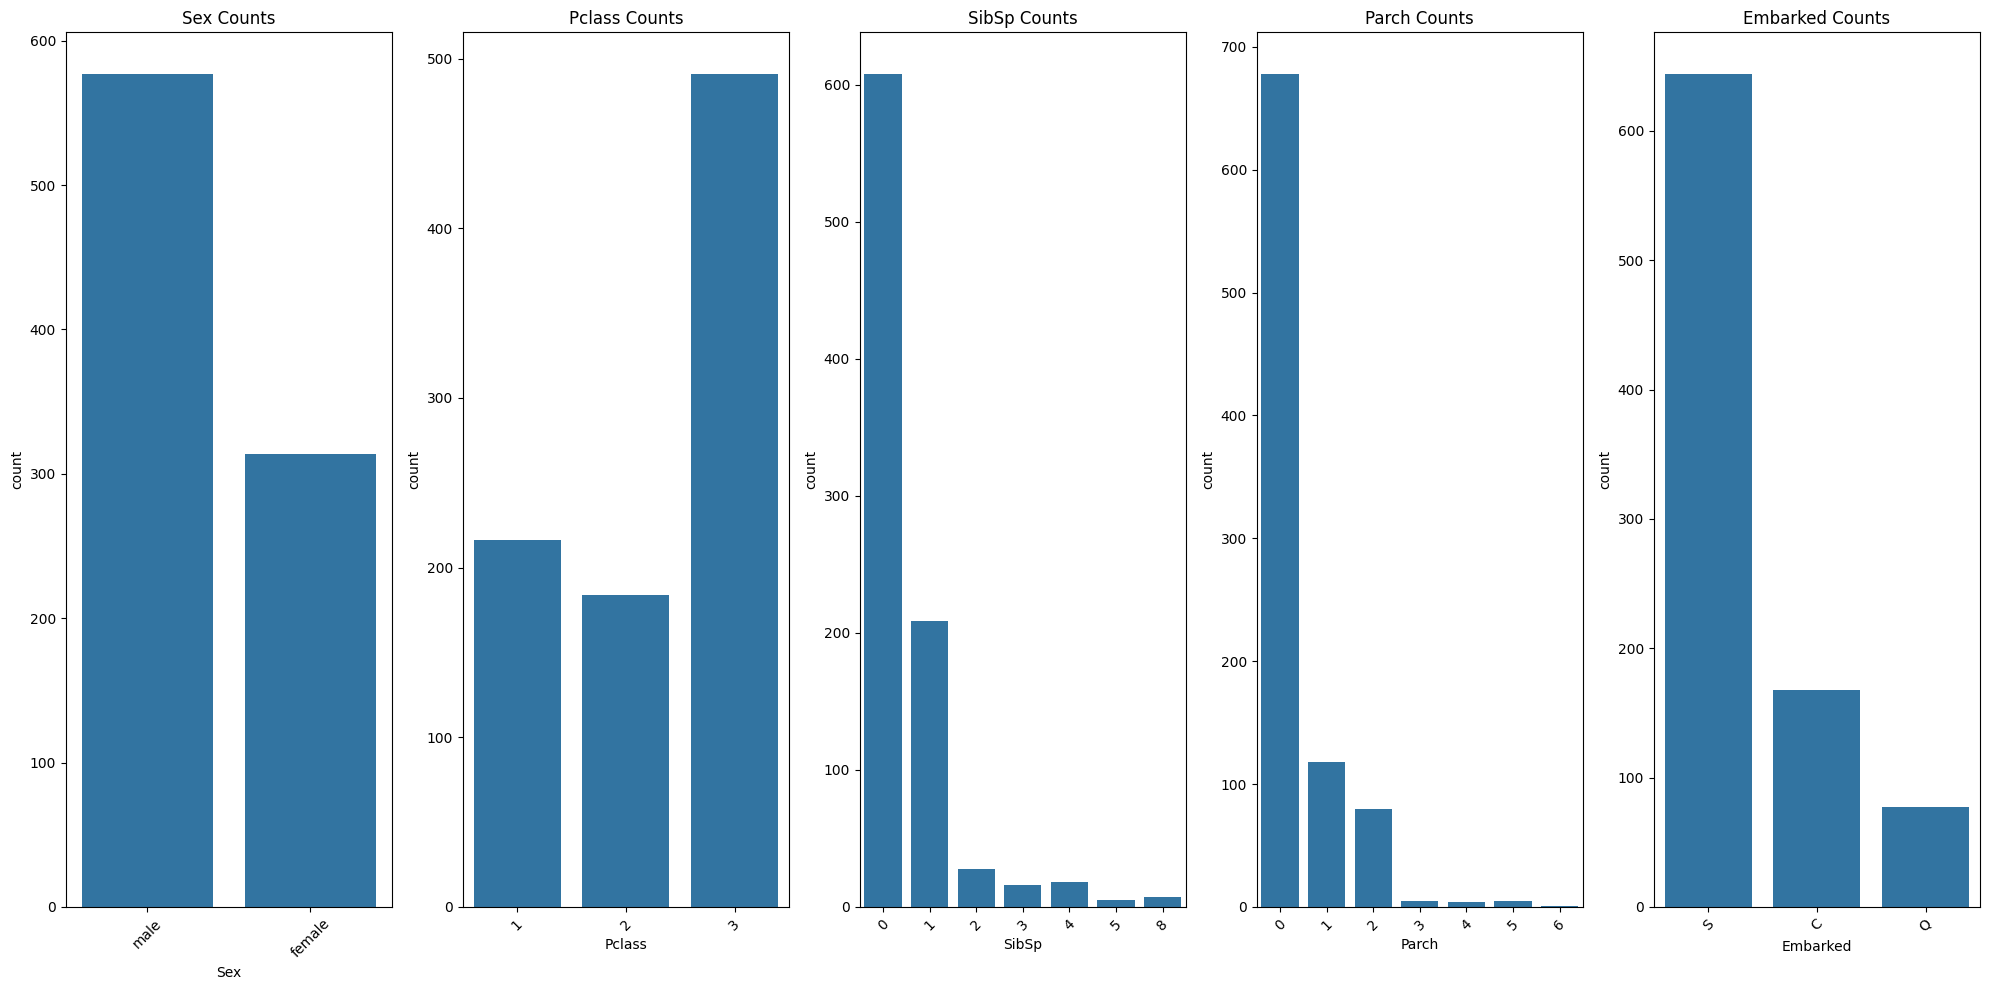

In [20]:

# Define the categorical columns to plot
countplot_cols = ['Sex', 'Pclass', 'SibSp', 'Parch', 'Embarked']

# Create a figure and a set of subplots
fig, axs = plt.subplots(1, 5, figsize=(20, 10))
axs = axs.flatten() # Flatten the axes array for easy iteration

# Loop through the columns and create a count plot for each
for i, col in enumerate(countplot_cols):
    sns.countplot(x=col, data=dftrain, ax=axs[i])
    axs[i].set_title(f'{col} Counts')
    axs[i].tick_params(axis='x', rotation=45)

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

#####3.4. Survival Analysis by Feature
Now for the most important part of EDA: how do different features relate to survival?

We will create new features (title, FareGroup, has_cabin) and then plot both the survival count and survival rate for each category within our key features. This will give us a clear idea of which groups had a higher chance of survival.

In [21]:
dftrain[['Name','Pclass', 'Sex', 'Age', 'SibSp','Parch','Cabin','Fare']].head(10)

,Name,Pclass,Sex,Age,SibSp,Parch,Cabin,Fare
0,"Braund, Mr. Owen Harris",3,male,22.0,1,0,NaN,7.2500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,female,38.0,1,0,C85,71.2833
2,"Heikkinen, Miss. Laina",3,female,26.0,0,0,NaN,7.9250
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,female,35.0,1,0,C123,53.1000
4,"Allen, Mr. William Henry",3,male,35.0,0,0,NaN,8.0500
5,"Moran, Mr. James",3,male,NaN,0,0,NaN,8.4583
6,"McCarthy, Mr. Timothy J",1,male,54.0,0,0,E46,51.8625
7,"Palsson, Master. Gosta Leonard",3,male,2.0,3,1,NaN,21.0750
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",3,female,27.0,0,2,NaN,11.1333
9,"Nasser, Mrs. Nicholas (Adele Achem)",2,female,14.0,1,0,NaN,30.0708


In [22]:
# Extract titles (e.g., Mr, Mrs, Miss) from the 'Name' column
dftrain['title'] = dftrain['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

In [23]:
# --- Feature Engineering for EDA ---

# Extract titles (e.g., Mr, Mrs, Miss) from the 'Name' column
dftrain['title'] = dftrain['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Consolidate titles into broader categories
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer', 'Major': 'Officer',
    'Mlle': 'Miss', 'Countess': 'Royal', 'Ms': 'Mrs', 'Lady': 'Royal',
    'Jonkheer': 'Royal', 'Don': 'Royal', 'Dona': 'Royal', 'Mme': 'Mrs',
    'Capt': 'Officer', 'Sir': 'Royal'
}
dftrain['title'] = dftrain['title'].map(title_mapping).fillna('Rare')
dftrain['title'].head(5)

,title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr


In [24]:
# Create fare groups by splitting 'Fare' into 4 quantiles (quartiles)
dftrain['FareGroup'] = pd.qcut(dftrain['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])
dftrain[['FareGroup','Fare']].head(10)

,FareGroup,Fare
0,Low,7.2500
1,Very High,71.2833
2,Medium,7.9250
3,Very High,53.1000
4,Medium,8.0500
5,Medium,8.4583
6,Very High,51.8625
7,High,21.0750
8,Medium,11.1333
9,High,30.0708


In [25]:
# Create a binary feature indicating if a passenger had a cabin number recorded
dftrain['has_cabin'] = dftrain['Cabin'].notnull().astype(int)
dftrain.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title,FareGroup,has_cabin
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S,Officer,Medium,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S,Miss,High,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S,Miss,High,0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C,Mr,High,1
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q,Mr,Low,0


In [26]:
# List of features to analyze against survival
survival_rate_cols = ['Sex', 'Pclass', 'SibSp', 'Parch', 'Embarked', 'title', 'FareGroup', 'has_cabin']

# Setup for subplots
n_cols = 2
n_rows = len(survival_rate_cols)

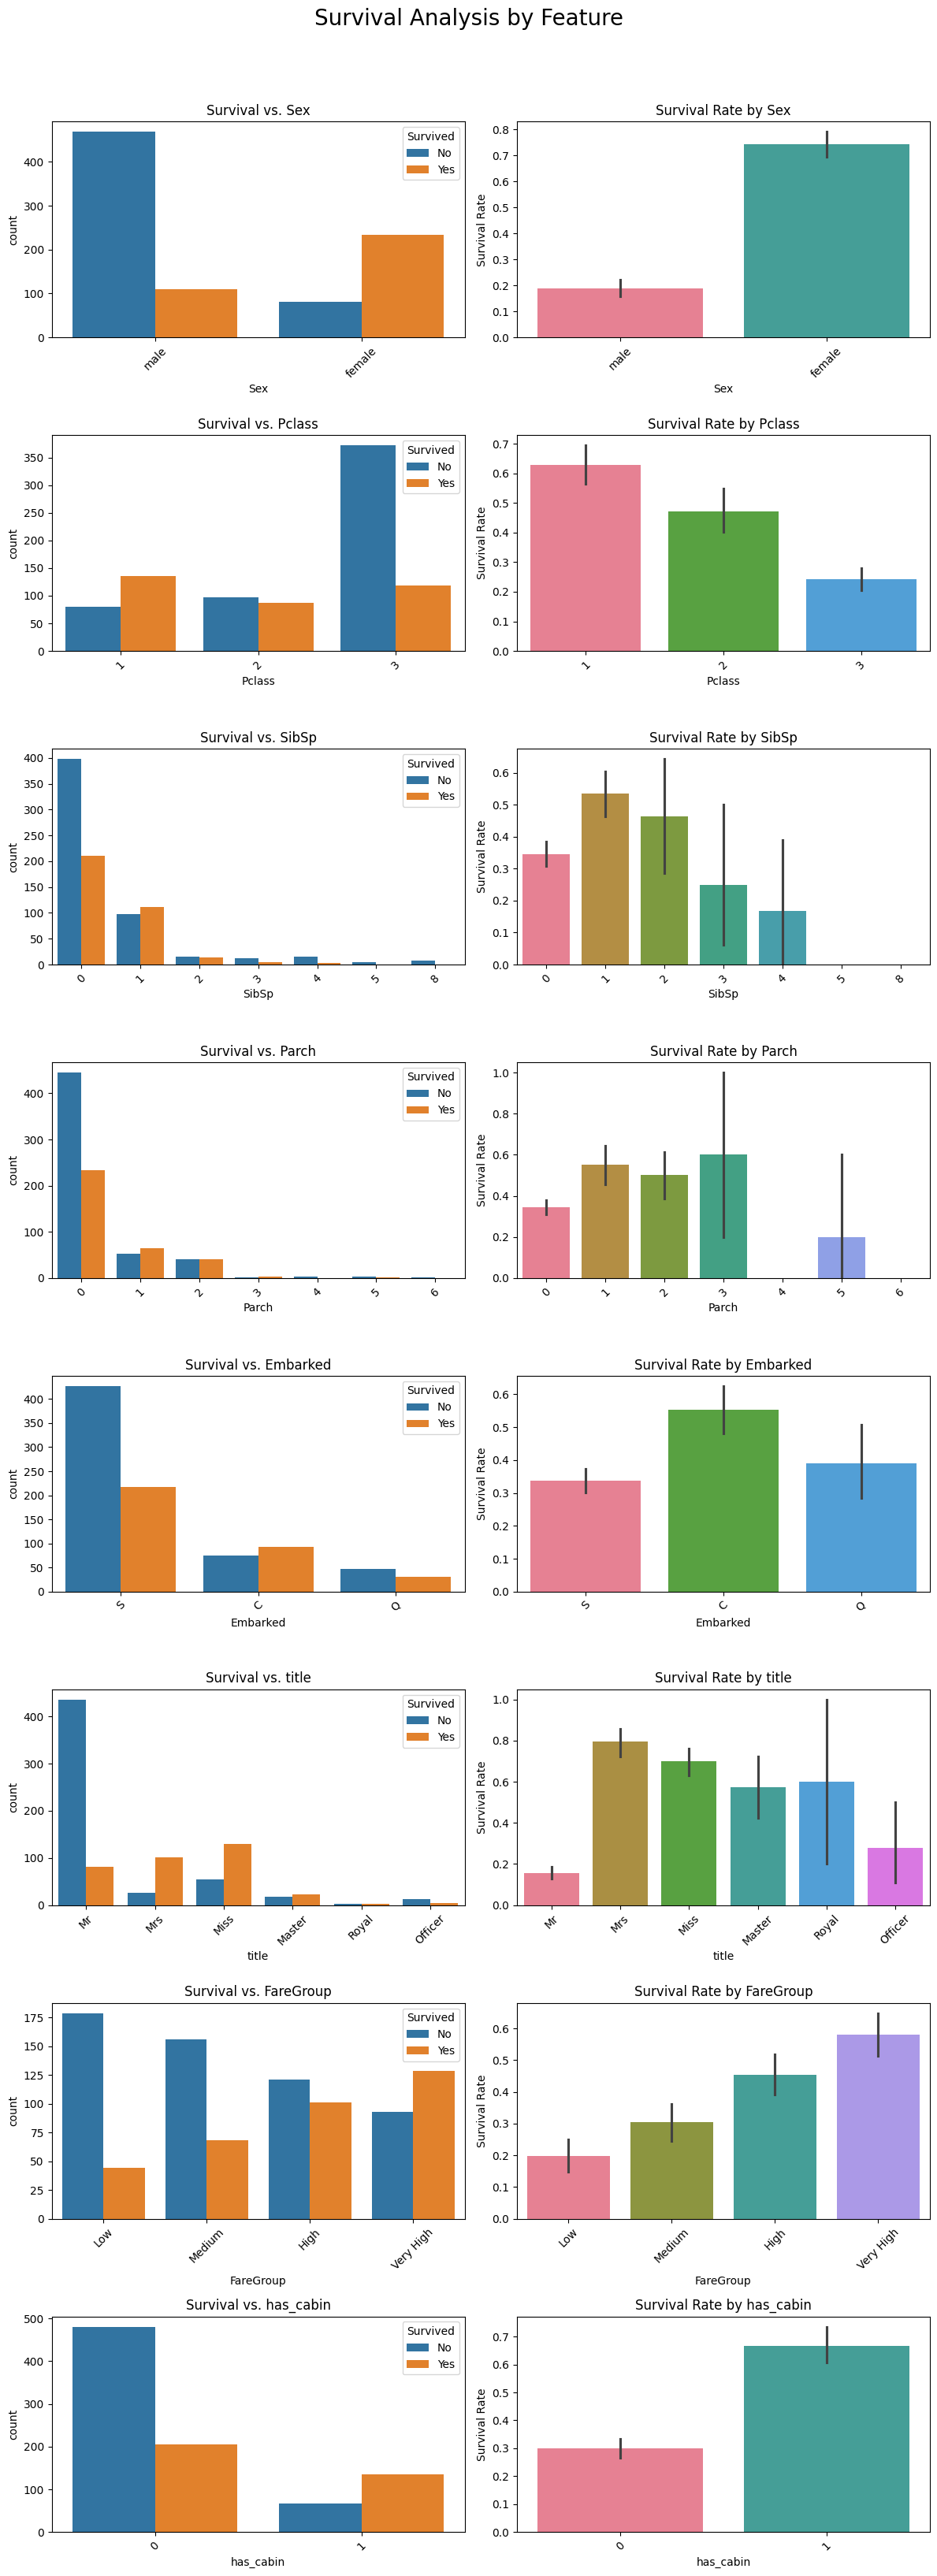

In [27]:
fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
fig.suptitle('Survival Analysis by Feature', fontsize=20, y=1.02)


for i, col in enumerate(survival_rate_cols):
    # Plot 1: Survival Count (e.g., how many men survived vs. didn't)
    sns.countplot(x=col,hue='Survived',data=dftrain,ax = axs[i,0])
    axs[i,0].set_title(f'Survival vs. {col}')
    axs[i,0].tick_params(axis='x', rotation=45)
    axs[i,0].legend(title='Survived', labels=['No', 'Yes'])

     # Plot 2: Survival Rate (e.g., what percentage of men survived)
    sns.barplot(x=col, y='Survived', data=dftrain, ax=axs[i, 1],palette='husl')
    axs[i, 1].set_title(f'Survival Rate by {col}')
    axs[i, 1].set_ylabel('Survival Rate')
    axs[i, 1].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0, 1, 1]) # Adjust layout to make space for suptitle
plt.show()

##### 3.5. Survival by Fare¶
A box plot is a great way to see the distribution of Fare for those who survived versus those who didn't. It appears that passengers who paid a higher fare had a better chance of survival.

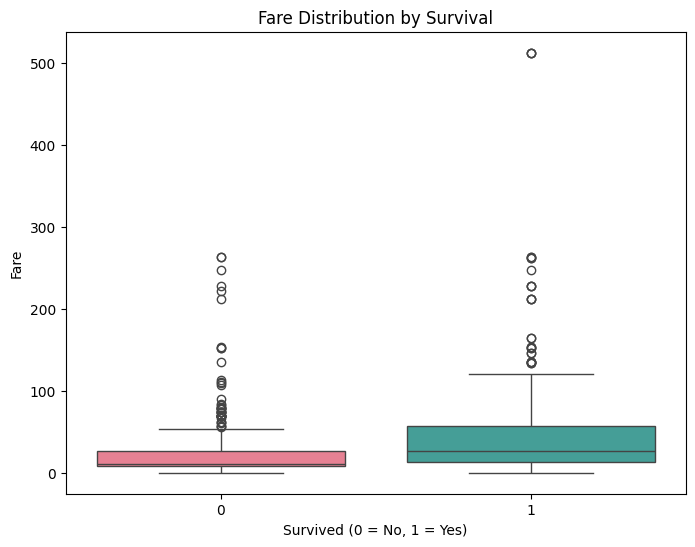

In [28]:
# Create a box plot to show the distribution of 'Fare' for each survival outcome
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Fare', data=dftrain,palette='husl')
plt.title('Fare Distribution by Survival')
plt.ylabel("Fare")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.show()

##### 3.6. Survival by Age Group
To better analyze the relationship between age and survival, we can group ages into bins and calculate the survival rate for each group

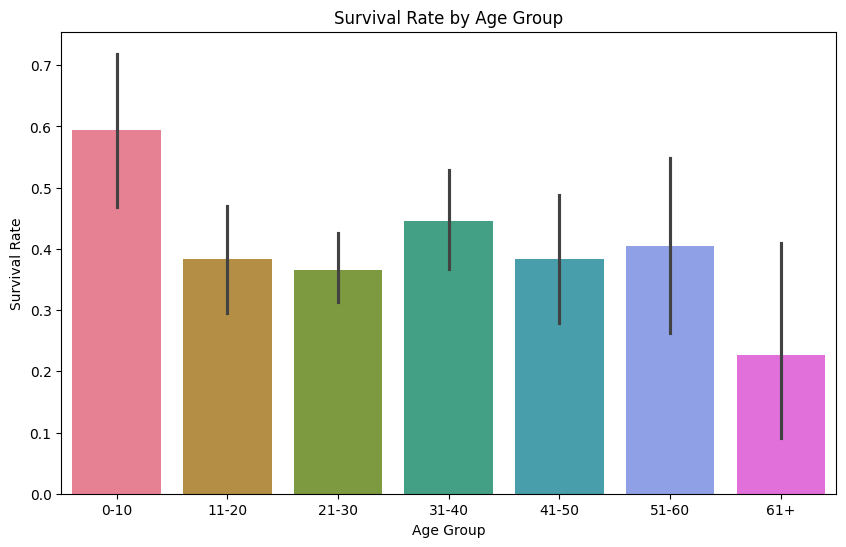

In [29]:
# Create age bins to group passengers
dftrain['AgeGroup'] = pd.cut(dftrain['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 80],
                             labels=['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61+'])

# Plot the survival rate for each age group
plt.figure(figsize=(10, 6))
sns.barplot(x='AgeGroup', y='Survived', data=dftrain,palette='husl')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')
plt.xlabel('Age Group')
plt.show()


#####3.7. Age Distribution by Survival (KDE)
A Kernel Density Estimate (KDE) plot provides a smoothed view of the age distribution for survivors and non-survivors. We can see that young children had a higher survival rate, while young adults (20-40) had a lower rate.

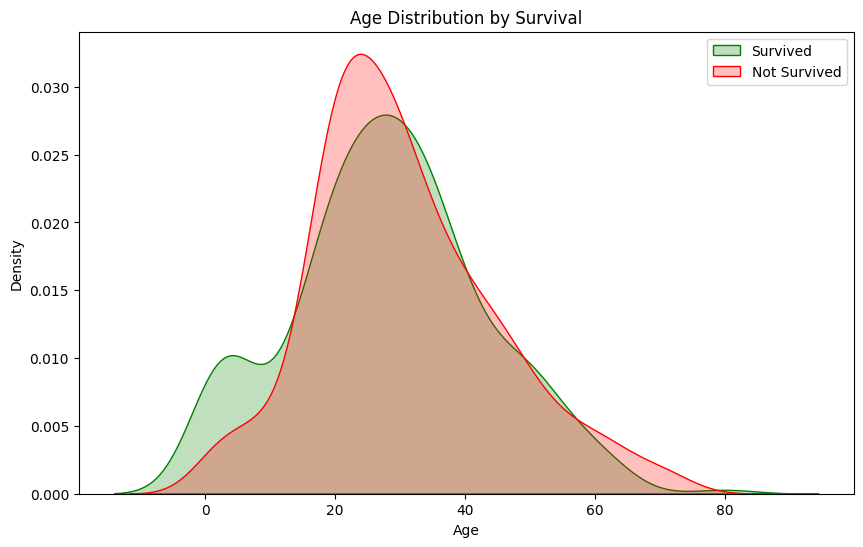

In [30]:
plt.figure(figsize=(10, 6))

# Plot KDE for survived passengers
sns.kdeplot(dftrain[dftrain['Survived'] == 1]['Age'], label='Survived', shade=True, color='green')
# Plot KDE for non-survived passengers
sns.kdeplot(dftrain[dftrain['Survived'] == 0]['Age'], label='Not Survived', shade=True, color='red')

plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.legend()
plt.show()

#### LEARNING PURPOSE

##### SelectKBest using Chi-Square Test (Categorical Features)

In [31]:
#from sklearn.model_selection import train_test_split #no need cause data is already give separatly
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import chi2, SelectKBest,f_classif

In [32]:
dftrain.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'title', 'FareGroup',
       'has_cabin', 'AgeGroup'],
      dtype='object')

In [33]:
#1.split data
X = dftrain.drop(['Survived','PassengerId','Name', 'Ticket','Cabin','AgeGroup','title'], axis=1)
y = dftrain['Survived']

In [34]:
X.isna().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2
FareGroup,0
has_cabin,0


In [35]:
X['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [36]:
#2. Handle missing Age
X['Age'].fillna(X['Age'].median(), inplace=True)
#X['Embarked'].fillna(X['Embarked'].mode()[0], inplace=True)
X['Embarked'].fillna('S', inplace=True)
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
FareGroup,0
has_cabin,0


In [37]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FareGroup,has_cabin
0,3,male,22.0,1,0,7.2500,S,Low,0
1,1,female,38.0,1,0,71.2833,C,Very High,1
2,3,female,26.0,0,0,7.9250,S,Medium,0
3,1,female,35.0,1,0,53.1000,S,Very High,1
4,3,male,35.0,0,0,8.0500,S,Medium,0
...,...,...,...,...,...,...,...,...,...
886,2,male,27.0,0,0,13.0000,S,Medium,0
887,1,female,19.0,0,0,30.0000,S,High,1
888,3,female,28.0,1,2,23.4500,S,High,0
889,1,male,26.0,0,0,30.0000,C,High,1


In [38]:
#3. Handle categorical variables (example: Sex, Embarked)
X['Sex'] = LabelEncoder().fit_transform(X['Sex'])
X['Embarked'] = LabelEncoder().fit_transform(X['Embarked'])
X['FareGroup'] = LabelEncoder().fit_transform(X['FareGroup'])

In [39]:
X

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FareGroup,has_cabin
0,3,1,22.0,1,0,7.2500,2,1,0
1,1,0,38.0,1,0,71.2833,0,3,1
2,3,0,26.0,0,0,7.9250,2,2,0
3,1,0,35.0,1,0,53.1000,2,3,1
4,3,1,35.0,0,0,8.0500,2,2,0
...,...,...,...,...,...,...,...,...,...
886,2,1,27.0,0,0,13.0000,2,2,0
887,1,0,19.0,0,0,30.0000,2,0,1
888,3,0,28.0,1,2,23.4500,2,0,0
889,1,1,26.0,0,0,30.0000,0,0,1


In [40]:
# 4. Apply filter method (chi2)
selector = SelectKBest(score_func=chi2, k=5)
X_selected = selector.fit_transform(X, y)

In [41]:
features = selector.get_support()
selected_features = X.columns[features]
selected_features

Index(['Pclass', 'Sex', 'Age', 'Fare', 'has_cabin'], dtype='object')

In [42]:
selector

SelectKBest(k=5, score_func=<function chi2 at 0x7bc35454b380>)

In [43]:
selector.scores_

array([3.08736994e+01, 9.27024470e+01, 2.16491630e+01, 2.58186538e+00,
       1.00974991e+01, 4.51831909e+03, 1.02025247e+01, 9.15631141e+00,
       6.89974116e+01])

In [44]:
df_columns = pd.DataFrame(X.columns)
df_scores = pd.DataFrame(selector.scores_)
Chi_Square = pd.concat([df_columns,df_scores],axis=1)

In [45]:
Chi_Square.columns = ['Specs','Score']
print(Chi_Square.nlargest(10,'Score'))

       Specs        Score
5       Fare  4518.319091
1        Sex    92.702447
8  has_cabin    68.997412
0     Pclass    30.873699
2        Age    21.649163
6   Embarked    10.202525
4      Parch    10.097499
7  FareGroup     9.156311
3      SibSp     2.581865


**Each feature gets a chi2 score.**

__k=5 → it keeps only the top 5 scoring features.__

When to change k?

_k = number of features to keep → you can try different values:_

k = 'all' → keeps all features but still ranks them.

_Choose k based on:_

Feature importance plots

Cross-validation scores

In [46]:
#scaler = MinMaxScaler()
#X_scaled = scaler.fit_transform(X)  # chi2 needs non-negative
#X_scaled

###### SelectKBest using f_classif

In [47]:
selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X, y)

# Get selected feature names
features = selector.get_support()
selected_features_f_classif = X.columns[features]

print("Selected Features using f_classif:")
print(selected_features_f_classif)

Selected Features using f_classif:
Index(['Pclass', 'Sex', 'Fare', 'Embarked', 'has_cabin'], dtype='object')


##### Variance Threshold

In [48]:
from sklearn.feature_selection import VarianceThreshold

In [49]:
selector_vt = VarianceThreshold(threshold=0.01)
dftrain_vt = selector_vt.fit_transform(X)

In [50]:
selector_vt.get_support()

array([ True,  True,  True,  True,  True,  True,  True,  True,  True])

In [51]:
selected_features_vt = pd.DataFrame(X.columns[selector_vt.get_support()])
selected_features_vt

,0
0,Pclass
1,Sex
2,Age
3,SibSp
4,Parch
5,Fare
6,Embarked
7,FareGroup
8,has_cabin


VarianceThreshold does not give scores like SelectKBest because:

__It is unsupervised → it just checks variance of each feature, not relation to the target (Survived).__

It only returns a mask of selected features (True/False) but no ranking or score.

##### CORR() TEST

In [52]:
X.head(5)

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FareGroup,has_cabin
0,3,1,22.0,1,0,7.2500,2,1,0
1,1,0,38.0,1,0,71.2833,0,3,1
2,3,0,26.0,0,0,7.9250,2,2,0
3,1,0,35.0,1,0,53.1000,2,3,1
4,3,1,35.0,0,0,8.0500,2,2,0


In [53]:
import numpy as np

In [54]:
correlation = [np.corrcoef(X[col],y)[0,1] for col in X.columns]
corr_df = pd.DataFrame({"Feature": X.columns, "Correlation": correlation})
corr_df

,Feature,Correlation
0,Pclass,-0.338481
1,Sex,-0.543351
2,Age,-0.064910
3,SibSp,-0.035322
4,Parch,0.081629
5,Fare,0.257307
6,Embarked,-0.167675
7,FareGroup,0.111219
8,has_cabin,0.316912


#### 4.Feature Engineering & Preprocessing¶
This is the most critical stage. We will create three main functions:

*feature_engineering_for_age:*

A sophisticated function based on some features that contains some features created based on correlation

*impute_age:*
A sophisticated function to fill missing Age values using an ensemble of LightGBM and Random Forest models.

*feature_engineering :*

A comprehensive function to create all our features, handle missing values, and encode categorical data.
This structured approach ensures that both the training and test data are processed identically.
First lets see correlation for Age.

In [55]:
dftrain.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title,FareGroup,has_cabin,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Low,0,21-30
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Very High,1,31-40
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Medium,0,21-30
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Very High,1,31-40
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Medium,0,31-40
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Mr,Medium,0,NaN
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,Mr,Very High,1,51-60
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,Master,High,0,0-10
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,Mrs,Medium,0,21-30
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,Mrs,High,0,11-20


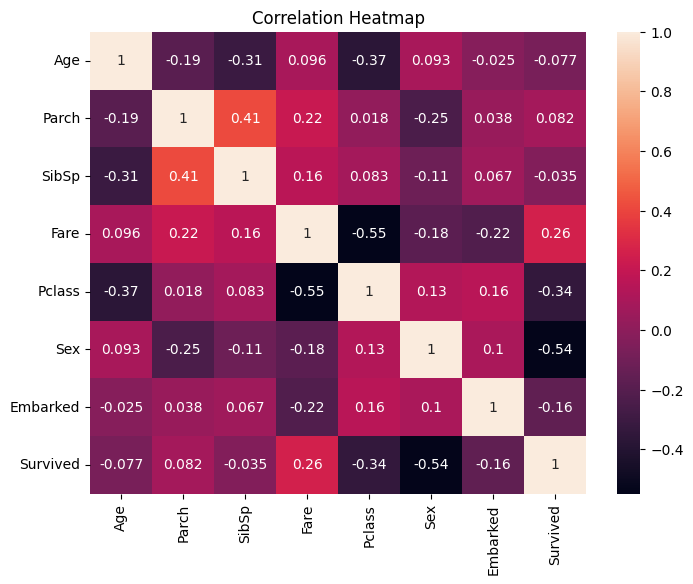

In [56]:
df_encoded = df_train_raw.copy()
cat_feat = ['Sex', 'Embarked']
for col in cat_feat:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
features_for_corr = ['Age', 'Parch', 'SibSp', 'Fare',
                     'Pclass', 'Sex', 'Embarked','Survived']
corr = df_encoded[features_for_corr].corr()
plt.figure(figsize= (8, 6))
sns.heatmap(corr, annot= True)
plt.title('Correlation Heatmap')
plt.show()

*+1 → Perfect positive correlation (both variables increase together).*

*-1 → Perfect negative correlation (one increases while the other decreases).*

*0 → No correlation (variables are unrelated).*


_Example (Titanic Dataset)_

1. If Fare has 0.55 correlation with Survival → Keep it.

2. If Ticket Number has 0.05 correlation → Drop it.

3. If Fare and Pclass have -0.85 correlation → keep one of them (or use regularization).

As you see these features doesn't related too much too Age.Let's see what we can do to created some better features.






**Key Observations**

1. Strong Negative Correlation
Fare vs Pclass → -0.55

Higher class (Pclass=1) → Higher fare (positive wealth).

Lower class (Pclass=3) → Lower fare (poorer passengers).

This is a strong relationship and makes sense logically.

2. Moderate Positive Correlation
Parch vs SibSp → 0.41

People traveling with parents/children (Parch) often also have siblings/spouses (SibSp) → Families travel together.

Feature engineering: these can be combined into one feature (e.g., FamilySize = SibSp + Parch).

3. Age vs Pclass → -0.37
Higher classes seem to have slightly older passengers (wealthier, older travelers).

4. Fare vs Other Features
Fare vs Age → 0.096 (weak) → Fare does not strongly depend on age.

Fare vs Parch/SibSp → weak positive correlation (0.22 / 0.16) → More family might mean slightly higher fare.

5. Sex vs Other Features
Sex vs Fare → -0.18 and other weak correlations → Sex is mostly independent of numeric features but will be important for target prediction (Survival).




*Goal:* Remove redundant features.

__Example:__ If Feature_A and Feature_B have correlation > 0.9, keep one to avoid multicollinearity.

__Limitations:__

Only detects linear relations (Pearson).

Does not consider feature importance with respect to target variable (except correlation with target).

##### 4.1. feature_engineering_for_age:

A sophisticated function based on some features that contains some features created based on correlation


In [57]:
def feature_engineering_for_age(df):
    """
    Performs feature engineering to create new variables and handle initial missing values.
    This function prepares features useful for general modeling tasks and especially for
    predicting missing 'Age' values.

    Args:
        df (pd.DataFrame): The input dataframe (train or test).

    Returns:
        Tuple[pd.DataFrame, List[str]]: The dataframe with engineered features,
        and a list of feature names useful for imputing 'Age'.
    """
    # Impute missing 'Fare' with the median fare of each passenger class
    if df['Fare'].isnull().any():
        median_fare = df.groupby('Pclass')['Fare'].transform('median')
        df['Fare'].fillna(median_fare, inplace=True)
    # Fill missing 'Embarked' with the most frequent port
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # ========== Feature Extraction ==========

    # Extract title from passenger names (e.g., Mr, Miss, Dr)
    df['title'] = df['Name'].str.extract('([A-Za-z]+)\.', expand=False)

    # Binary indicator for presence of cabin information
    df['has_cabin'] = df['Cabin'].notnull().astype(int)

    # Calculate family size including the passenger
    df['family_size'] = df['SibSp'] + df['Parch'] + 1

    # Extract deck letter from Cabin (can be multiple for shared cabins)
    df['decks'] = df['Cabin'].str.findall(r'([A-Za-z])')

    # Count how many people share the same ticket (ticket group size)
    df['ticket_group_size'] = df.groupby('Ticket')['Ticket'].transform('count')

    # ========== Title Grouping and Encoding ==========

    # Map raw titles to broader, standardized categories
    title_mapping = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer', 'Major': 'Officer',
        'Mlle': 'Miss', 'Countess': 'Royal', 'Ms': 'Mrs', 'Lady': 'Royal',
        'Jonkheer': 'Royal', 'Don': 'Royal', 'Dona': 'Royal', 'Mme': 'Mrs',
        'Capt': 'Officer', 'Sir': 'Royal'
            }
    df['title'] = df['title'].map(title_mapping).fillna('Rare')

    # Fill missing decks with placeholder
    df['decks'] = df['decks'].fillna('Unknown')

    # Encode title as numerical feature
    le = LabelEncoder()
    df['title_encoded'] = le.fit_transform(df['title'])

    # ========== Derived and Interaction Features ==========

    # Indicator: whether the passenger is a child (Master)
    df['is_child'] = (df['title'] == 'Master').astype(int)

    # Indicator: whether the passenger is likely a parent (Mr or Mrs with family)
    df['is_parent'] = ((df['title'].isin(['Mr', 'Mrs'])) & (df['family_size'] > 1)).astype(int)

    # Cabin wealth feature: fare adjusted by cabin presence
    df['cabin_wealth'] = df['has_cabin'] * np.log1p(df['Fare'])

    # Difference between total family size and number of parents/children
    df['family_size_parch'] = df['family_size'] - df['Parch']

    # Interaction of ticket group size with passenger class
    df['ticket_size_class'] = df['ticket_group_size'] * df['Pclass']
     # Interaction categorical features for modeling
    df['title_decks'] = df['title'].astype(str) + '_' + df['decks'].astype(str)
    df['title_sex'] = df['title'].astype(str) + '_' + df['Sex'].astype(str)

    # Numerical interaction features
    df['title_family_size'] = df['title_encoded'] * df['family_size']
    df['title_fare'] = df['title_encoded'] * df['Fare']

    # ========== Features Useful for Age Imputation ==========
    age_features = [
        'title_encoded', 'title_decks', 'title_sex', 'is_parent', 'cabin_wealth',
        'title_fare', 'title_family_size', 'ticket_group_size', 'is_child',
        'family_size_parch', 'ticket_size_class'
    ]

    # ========== Metadata and Logging ==========
    df.attrs['name'] = 'Raw DataFrame'
    print(f"The {df.attrs['name']} has filled these new features for missing age imputation.")
    print(f"New features used for imputing age:\n{', '.join(age_features)}")

    return df, age_features

In [58]:
#train
df_train_raw2, age_features = feature_engineering_for_age(df_train_raw)

The Raw DataFrame has filled these new features for missing age imputation.
New features used for imputing age:
title_encoded, title_decks, title_sex, is_parent, cabin_wealth, title_fare, title_family_size, ticket_group_size, is_child, family_size_parch, ticket_size_class


In [59]:
#test
df_test_raw2, _ = feature_engineering_for_age(df_test_raw)

The Raw DataFrame has filled these new features for missing age imputation.
New features used for imputing age:
title_encoded, title_decks, title_sex, is_parent, cabin_wealth, title_fare, title_family_size, ticket_group_size, is_child, family_size_parch, ticket_size_class


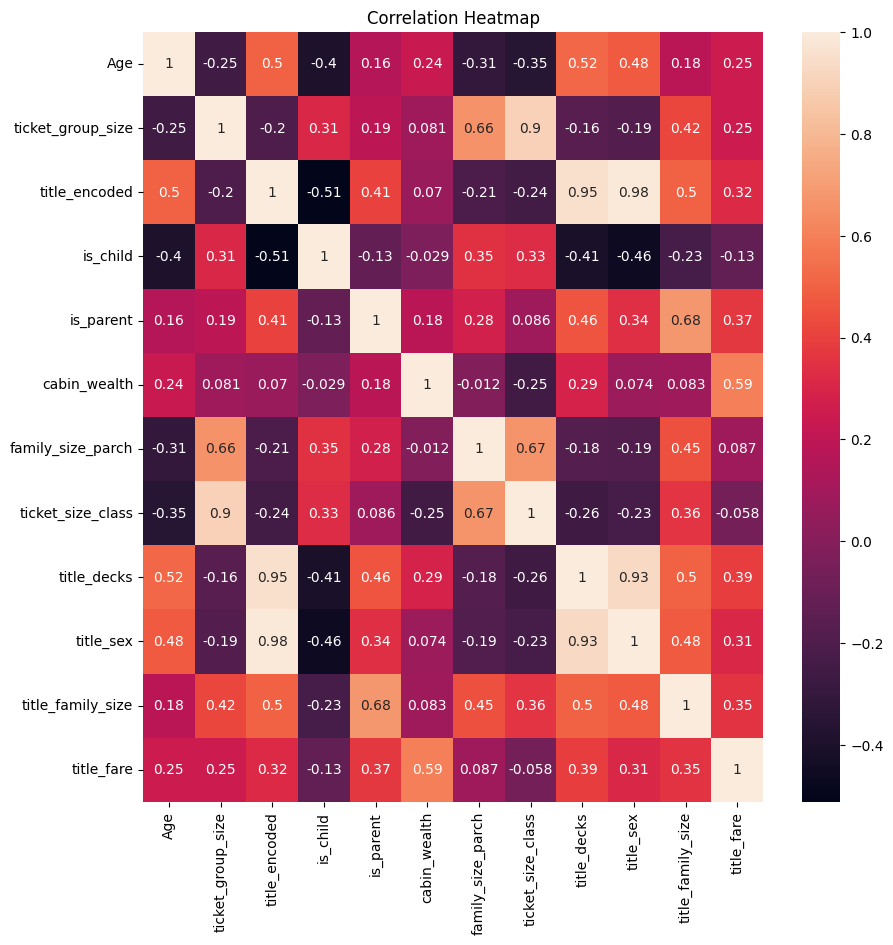

In [60]:
df_enc = df_train_raw2.copy()
df_enc.drop(['Survived', 'Ticket', 'Name', 'PassengerId', 'Cabin'], axis= 1, inplace= True)
cat_feat = ['title_decks', 'title_sex', 'Sex']
for col in cat_feat:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

corr_feat = ['Age', 'ticket_group_size', 'title_encoded', 'is_child',
       'is_parent', 'cabin_wealth', 'family_size_parch', 'ticket_size_class',
       'title_decks', 'title_sex', 'title_family_size', 'title_fare',
]
corr = df_enc[corr_feat].corr()
plt.figure(figsize= (10, 10))
sns.heatmap(corr, annot= True)
plt.title('Correlation Heatmap')
plt.show()

as you see now we have stronger features to impute age based on these.
Let's do it!

##### 4.2. Age Imputation with LightGBM and Random Forest¶

This function fills missing Age values using a weighted average of predictions from:

LightGBM (default weight = 0.6)
Random Forest (default weight = 0.4)

It trains both models on rows with known ages using age_features, then imputes the missing values. Predictions are clipped between 0 and 80 for realism.

Returns: Updated DataFrame with imputed Age.


**Robustness to Data Patterns:**
Both RFR and LightGBM are powerful tree-based algorithms that can handle complex, nonlinear relationships in your features. This makes them well-suited to accurately predict age from diverse types of data (numerical, categorical, etc.), even when the pattern isn't obvious.

**Handling Outliers and Nonlinearities:**
 Unlike simple imputation strategies (like mean or median), these algorithms aren't as sensitive to outliers and can better capture patterns between features and target (Age), making their predictions generally more reliable.

**Ensemble of Models Increases Reliability:**

 Using two different models and combining their predictions (weighted average) improves imputation accuracy. Each model may capture different aspects of the data, reducing the risk of systematic bias from any single approach.





In [61]:
def impute_age(df, age_features= age_features, lgb_weight=0.6, rf_weight=0.4):
    """
    Imputes missing 'Age' values using a weighted ensemble of LightGBM and
    Random Forest regressors.

    This function:
    - Splits the data into rows with known and missing ages.
    - Trains LightGBM and Random Forest models on known age data.
    - Predicts the missing ages using both models.
    - Creates a weighted ensemble of the predictions.
    - Fills in the missing 'Age' values using the ensemble output.

    Args:
        df (pd.DataFrame): The input dataframe (train or test).
        age_features (List[str]): The feature list used to predict age.
        lgb_weight (float): Weight of LightGBM model in the ensemble.
        rf_weight (float): Weight of Random Forest model in the ensemble.

    Returns:
        pd.DataFrame: The dataframe with missing 'Age' values imputed.
    """
    # Make a copy to avoid modifying the original dataframe
    df_temp = df.copy()

    # --- Step 2: Split data into known and unknown age groups ---
    age_known_df = df_temp[df_temp['Age'].notnull()]
    age_missing_df = df_temp[df_temp['Age'].isnull()]

    # If no ages are missing, return the original dataframe
    if age_missing_df.empty:
        return df

    # Prepare training data (X) and target (y)
    X_train_age = age_known_df[age_features]
    y_train_age = age_known_df['Age']
    X_pred_age = age_missing_df[age_features]

    # Prepare data for both models
    X_train_lgb = X_train_age.copy()
    X_pred_lgb = X_pred_age.copy()
    X_train_rf = X_train_age.copy()
    X_pred_rf = X_pred_age.copy()

    # --- Step 3: Train and predict with LightGBM ---
    categorical_cols = ['title_sex', 'title_decks', 'title_encoded']
    for col in categorical_cols:
        X_train_lgb[col] = X_train_lgb[col].astype('category')
        X_pred_lgb[col] = X_pred_lgb[col].astype('category')
    lgb_model = LGBMRegressor(
        objective='regression',
        n_estimators=80,
        learning_rate=0.08,
        num_leaves=15,
        min_child_samples=15,
        min_split_gain=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=SEED,
        verbose=-1
            )

    lgb_model.fit(X_train_lgb, y_train_age, categorical_feature=categorical_cols)
    lgb_pred = lgb_model.predict(X_pred_lgb)

    # --- Step 4: Train and predict with Random Forest ---
    # Encode categorical features for Random Forest
    for col in ['title_decks', 'title_sex']:
        le = LabelEncoder()
        X_train_rf[col] = le.fit_transform(X_train_rf[col])
        X_pred_rf[col] = le.fit_transform(X_pred_rf[col])
    rf_model = RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        min_samples_split=8,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=SEED,
        n_jobs=-1
    )
    rf_model.fit(X_train_rf, y_train_age)
    rf_pred = rf_model.predict(X_pred_rf)

    # --- Step 5: Create weighted ensemble prediction ---
    # Combine predictions, giving slightly more weight to LGBM
    ensemble_pred = (lgb_weight * lgb_pred) + (rf_weight * rf_pred)
    ensemble_pred = np.clip(np.round(ensemble_pred), 0, 80) # Clip predictions to a realistic age range

    # --- Step 6: Fill in the missing ages in the original dataframe ---
    missing_age_indices = df[df['Age'].isnull()].index

    if len(missing_age_indices) == len(ensemble_pred):
        df.loc[missing_age_indices, 'Age'] = ensemble_pred
        print(f"Filled {len(ensemble_pred)} missing 'Age' values.")
        print(f"LightGBM weight: {lgb_weight}, Random Forest weight: {rf_weight}")
    else:
        print("⚠️ Warning: Length mismatch in age imputation. Skipping filling step.")
        print(f"Expected {len(missing_age_indices)} values, but got {len(ensemble_pred)} predictions.")

    return df

In [62]:
df_train_raw2.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'title', 'has_cabin',
       'family_size', 'decks', 'ticket_group_size', 'title_encoded',
       'is_child', 'is_parent', 'cabin_wealth', 'family_size_parch',
       'ticket_size_class', 'title_decks', 'title_sex', 'title_family_size',
       'title_fare'],
      dtype='object')

In [63]:
def df_cleaning(df):
    """
    Removes temporary or intermediate features from the DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame to clean.

    Returns:
        pd.DataFrame: The cleaned DataFrame without the specified features.
    """
    # List of engineered features used earlier (e.g., for age imputation) that are no longer needed
    cleaned_features = ['title_encoded', 'decks', 'title_family_size',
                        'title_fare', 'title_decks', 'title_sex']

    # Drop these columns from the DataFrame
    df.drop(cleaned_features, axis=1, inplace=True)

    # Log the cleanup
    print(f"{', '.join(cleaned_features)} has cleaned from DataFrame")

    return df

In [64]:
df_train_age_filled = impute_age(df_train_raw2, age_features, lgb_weight=0.6, rf_weight= 0.4)
df_test_age_filled = impute_age(df_test_raw2, age_features, lgb_weight=0.6, rf_weight= 0.4)

Filled 177 missing 'Age' values.
LightGBM weight: 0.6, Random Forest weight: 0.4
Filled 86 missing 'Age' values.
LightGBM weight: 0.6, Random Forest weight: 0.4


Cleaning cols whihc we added

In [65]:
df_train_intermediate = df_cleaning(df_train_age_filled)

title_encoded, decks, title_family_size, title_fare, title_decks, title_sex has cleaned from DataFrame


In [66]:
df_test_intermediate = df_cleaning(df_test_age_filled)

title_encoded, decks, title_family_size, title_fare, title_decks, title_sex has cleaned from DataFrame


##### 4.3. Main Feature Engineering Function

This function is the heart of our data preparation pipeline.

It takes an intermediate dataframe that created after age imputation and transforms it into a feature-rich dataset ready for a neural network.

Fitting All Encoders on Train and Test Data
The function below fits all LabelEncoders required for feature engineering on the union of both train and test datasets.

This ensures every possible class (including 'Unknown' or 'None') is recognized and prevents unseen-label errors when transforming either dataset.



In [67]:
def fit_all_encoders(df_train_raw, df_test_raw):
    """
    Fits label encoders on combined train and test sets for various categorical features
    to ensure consistent encoding across both datasets.

    Args:
        df_train_raw (pd.DataFrame): Raw training DataFrame.
        df_test_raw (pd.DataFrame): Raw test DataFrame.

    Returns:
        dict: A dictionary containing fitted LabelEncoders for:
            - title_grouped
            - primary_deck
    """

    # --- Title Grouped ---
    # Extract and normalize titles from names, then map them to grouped categories
    train_titles = df_train_raw['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
    test_titles = df_test_raw['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

    title_mapping = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master', 'Dr': 'Officer',
        'Rev': 'Officer', 'Col': 'Officer', 'Major': 'Officer', 'Mlle': 'Miss',
        'Countess': 'Royal', 'Ms': 'Mrs', 'Lady': 'Royal', 'Jonkheer': 'Royal',
        'Don': 'Royal', 'Dona': 'Royal', 'Mme': 'Mrs', 'Capt': 'Officer', 'Sir': 'Royal'
    }

    all_titles = pd.concat([train_titles, test_titles], ignore_index=True)
    all_titles_grouped = all_titles.map(title_mapping).fillna('Rare').unique()

    le_title_grouped = LabelEncoder()
    le_title_grouped.fit(all_titles_grouped)

    # --- Primary Deck ---
    # Extract first letter from Cabin as deck information, fill missing with 'Unknown'
    train_decks = df_train_raw['Cabin'].str.extract(r'^([A-Za-z])', expand=False).fillna('Unknown')
    test_decks = df_test_raw['Cabin'].str.extract(r'^([A-Za-z])', expand=False).fillna('Unknown')

    all_decks = pd.concat([train_decks, test_decks], ignore_index=True).unique()

    le_deck = LabelEncoder()
    le_deck.fit(all_decks)

    return {
        'title_grouped': le_title_grouped,
        'primary_deck': le_deck
    }

Final Feature Engineering for Neural Network Models
This function builds on top of the earlier feature_engineering_for_age().

*✅ Assumptions:*

Some features like title, family_size, has_cabin, and cabin_wealth already exist.
Temporary features created earlier (e.g. title_decks, title_sex) have already been cleaned.

_What it adds:_


Encoded categorical features: title_encoded, deck_encoded, embarked_encoded, etc.
Interaction features tailored for neural networks.
New numerical features like fare_per_person_log, social_status, and more.
Logical groups for wealth, family, survival relevance, and social status.
Returns the final, enhanced DataFrame for deep learning models

In [68]:
def feature_engineering(df, encoders):
    """
    Enhanced feature engineering specifically optimized for neural networks.
    Assumes some features were already created in feature_engineering_for_age and later cleaned.
    """
    df = df.copy()

    # Deck and cabin counts
    df['num_decks'] = df['Cabin'].apply(
        lambda x: 1 if pd.isnull(x) else len(re.findall(r'[A-Za-z]', x))
    )
    df['num_cabins'] = df['Cabin'].apply(lambda x: 1 if pd.isnull(x) else len(x.split()))

    # Alone indicator
    df['is_alone'] = (df['family_size'] == 1).astype(int)

    # Primary deck extraction and cleanup
    df['primary_deck'] = df['Cabin'].str.extract(r'^([A-Za-z])', expand=False)
    df['primary_deck'] = df['primary_deck'].fillna('Unknown')
    df['Cabin'] = df['Cabin'].fillna('Unknown')

    # Family type classification
    df['family_type'] = 'Single'
    df.loc[df['family_size'] == 2, 'family_type'] = 'Couple'
    df.loc[(df['family_size'] >= 3) & (df['family_size'] <= 4), 'family_type'] = 'Small_Family'
    df.loc[df['family_size'] >= 5, 'family_type'] = 'Large_Family'
    # Ticket prefix and binary indicator
    df['ticket_prefix'] = df['Ticket'].str.extract('([A-Za-z]+)', expand=False).fillna('None')
    df['has_ticket_prefix'] = (df['ticket_prefix'] != 'None').astype(int)

    # Encoding Sex
    df['sex_encoded'] = df['Sex'].map({'male': 1, 'female': 0})

    # Label encode using pre-fitted encoders
    df['title_encoded'] = encoders['title_grouped'].transform(df['title'])
    df['deck_encoded'] = encoders['primary_deck'].transform(df['primary_deck'])

    # Log-transform fares
    df['log_fare'] = np.log1p(df['Fare'])
    df['fare_per_person'] = df['Fare'] / df['family_size']
    df['fare_per_person_log'] = np.log1p(df['fare_per_person'])

    # Bin fare and age into quantiles and groups
    df['fare_quartile'] = pd.qcut(df['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very High'])
    df['age_group'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teenager', 'Adult', 'Old', 'Very Old'])

    # Interaction features for NN
    df['age_class'] = df['Age'] * df['Pclass']
    df['fare_class'] = df['log_fare'] * df['Pclass']
    df['sex_class'] = df['sex_encoded'] * df['Pclass']
    df['title_class'] = df['title_encoded'] * df['Pclass']
    df['deck_class'] = df['deck_encoded'] * df['Pclass']
    df['family_fare'] = df['family_size'] * df['log_fare']
    df['title_age'] = df['title_encoded'] * df['Age']
    df['cabin_class'] = df['has_cabin'] * df['Pclass']

    # Social status interaction
    df['title_family_interaction'] = df['title_encoded'] * df['family_size']
    df['wealth_indicator'] = df['cabin_wealth'] + df['log_fare'] + (df['Pclass'] * -1)

    # Survival-related features
    df['women_children_first'] = ((df['sex_encoded'] == 0) | (df['Age'] < 16)).astype(int)
    df['adult_male'] = ((df['sex_encoded'] == 1) & (df['Age'] >= 16)).astype(int)
    df['family_with_cabin'] = df['family_size'] * df['has_cabin']

    # Social status score based on multiple traits
    df['social_status'] = (
        (df['Pclass'] == 1).astype(int) * 3 +
        df['has_cabin'] * 2 +
        df['has_ticket_prefix'] * 1 +
        (df['title_encoded'] == encoders['title_grouped'].transform(['Royal'])[0]) * 4
    )

    print(f"All new features added Successfully!\nAll Features:\n{', '.join(df.columns)}\nNumber of features: {len(df.columns)}")

    return df

In [69]:
# 1. Fit all encoders on the union of train & test data
# IMPORTANT: USE INTERMEDIATE DFs
encoders = fit_all_encoders(df_train_raw, df_test_raw)

# Process the training data
df_train_processed = feature_engineering(df_train_intermediate, encoders= encoders)

# Process the test data
df_test_processed = feature_engineering(df_test_intermediate, encoders= encoders)

All new features added Successfully!
All Features:
PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked, title, has_cabin, family_size, ticket_group_size, is_child, is_parent, cabin_wealth, family_size_parch, ticket_size_class, num_decks, num_cabins, is_alone, primary_deck, family_type, ticket_prefix, has_ticket_prefix, sex_encoded, title_encoded, deck_encoded, log_fare, fare_per_person, fare_per_person_log, fare_quartile, age_group, age_class, fare_class, sex_class, title_class, deck_class, family_fare, title_age, cabin_class, title_family_interaction, wealth_indicator, women_children_first, adult_male, family_with_cabin, social_status
Number of features: 50
All new features added Successfully!
All Features:
PassengerId, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked, title, has_cabin, family_size, ticket_group_size, is_child, is_parent, cabin_wealth, family_size_parch, ticket_size_class, num_decks, num_cabins, is_alone, prima

In [70]:
df_train_processed

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,deck_class,family_fare,title_age,cabin_class,title_family_interaction,wealth_indicator,women_children_first,adult_male,family_with_cabin,social_status
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,24,4.220426,44.0,0,4,-0.889787,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,2,8.561186,114.0,1,6,7.561186,1,0,2,6
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,24,2.188856,26.0,0,1,-0.811144,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,2,7.981668,105.0,1,6,6.981668,1,0,2,5
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,24,2.202765,70.0,0,2,-0.797235,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,...,16,2.639057,108.0,0,4,0.639057,0,1,0,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,...,1,3.433987,19.0,1,1,5.867974,1,0,1,5
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,7.0,1,2,W./C. 6607,23.4500,...,24,12.786521,7.0,0,4,0.196630,1,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,...,2,3.433987,52.0,1,2,5.867974,0,1,1,5


In [71]:
df_train_processed.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,title,has_cabin,family_size,ticket_group_size,is_child,is_parent,cabin_wealth,family_size_parch,ticket_size_class,num_decks,num_cabins,is_alone,primary_deck,family_type,ticket_prefix,has_ticket_prefix,sex_encoded,title_encoded,deck_encoded,log_fare,fare_per_person,fare_per_person_log,fare_quartile,age_group,age_class,fare_class,sex_class,title_class,deck_class,family_fare,title_age,cabin_class,title_family_interaction,wealth_indicator,women_children_first,adult_male,family_with_cabin,social_status,
891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,Unknown,Q,Mr,0,1,1,0,0,0.000000,1,3,1,1,1,Unknown,Single,None,0,1,2,8,2.169054,7.75000,2.169054,Low,Adult,96.0,6.507161,3,6,24,2.169054,64.0,0,2,-0.830946,0,1,0,0,1
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,Mr,0,2,1,0,1,0.000000,2,3,1,1,0,Unknown,Couple,A,1,1,2,8,2.110213,3.62500,1.531476,Low,Adult,66.0,6.330640,3,6,24,4.220426,44.0,0,4,-0.889787,0,1,0,1,1
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,2,1,0,1,4.280593,2,1,1,1,0,C,Couple,PC,1,0,3,2,4.280593,35.64165,3.601186,Very High,Old,38.0,4.280593,0,3,2,8.561186,114.0,1,6,7.561186,1,0,2,6,1
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,Miss,0,1,1,0,0,0.000000,1,3,1,1,1,Unknown,Single,STON,1,0,1,8,2.188856,7.92500,2.188856,Medium,Adult,78.0,6.566569,0,3,24,2.188856,26.0,0,1,-0.811144,1,0,0,1,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1,2,2,0,1,3.990834,2,2,1,1,0,C,Couple,None,0,0,3,2,3.990834,26.55000,3.316003,Very High,Adult,35.0,3.990834,0,3,2,7.981668,105.0,1,6,6.981668,1,0,2,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,Unknown,C,Royal,0,1,1,0,0,0.000000,1,1,1,1,1,Unknown,Single,PC,1,1,5,8,3.357622,27.72080,3.357622,High,Old,40.0,3.357622,1,5,8,3.357622,200.0,0,5,2.357622,0,1,0,8,1
32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,33.0,1,0,PC 17569,146.5208,B78,C,Mrs,1,2,2,0,1,4.993969,2,2,1,1,0,B,Couple,PC,1,0,3,1,4.993969,73.26040,4.307578,Very High,Adult,33.0,4.993969,0,3,1,9.987938,99.0,1,6,8.987938,1,0,2,6,1
33,1,3,"Glynn, Miss. Mary Agatha",female,23.0,0,0,335677,7.7500,Unknown,Q,Miss,0,1,1,0,0,0.000000,1,3,1,1,1,Unknown,Single,None,0,0,1,8,2.169054,7.75000,2.169054,Low,Adult,69.0,6.507161,0,3,24,2.169054,23.0,0,1,-0.830946,1,0,0,0,1


#####4.4.Feature selection

**Feature Importance**

In [72]:
X = df_train_processed.drop([
    'Survived',
    'family_type',
    'ticket_prefix',
    'Ticket',
    'Name',
    'primary_deck',
    'PassengerId',
    'Cabin',
    'Sex',
    'Embarked',
    'title',
    'fare_quartile',    # added categorical columns to remove
    'age_group'
], axis=1)

y = df_train_processed['Survived']


In [73]:
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier()
model.fit(X,y)

ExtraTreesClassifier()

In [74]:
model.feature_importances_

array([0.02788181, 0.05922486, 0.01169889, 0.00690457, 0.03122276,
       0.01067716, 0.01277323, 0.02087302, 0.00470812, 0.00365532,
       0.01782482, 0.0104326 , 0.02890197, 0.00119631, 0.00157178,
       0.00604313, 0.01038384, 0.07424346, 0.01717686, 0.01293287,
       0.03317083, 0.03188024, 0.03082553, 0.06371235, 0.03990572,
       0.04526567, 0.01751184, 0.02899971, 0.03139655, 0.05780558,
       0.00495019, 0.01109415, 0.03909717, 0.08885954, 0.0852083 ,
       0.00478632, 0.01520292])

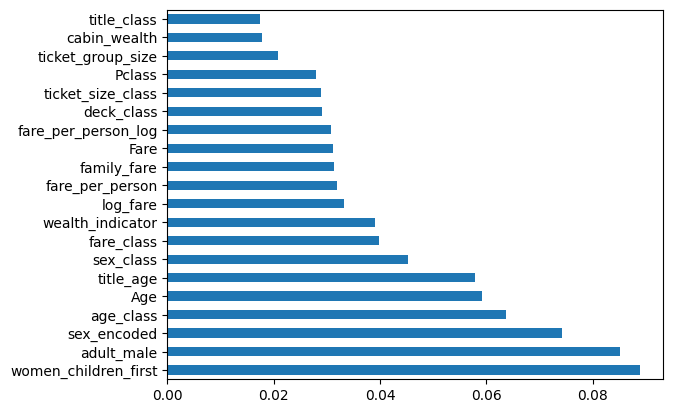

In [75]:
#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

#####4.5.Wrapper method

###### 4.5.1. Forward Selection — SFS() from mlxtendSequential Feature Selector**

SFS Classifier

**When to Use?**

__Logistic Regression__

Data is mostly linear, features are independent, or you want interpretability.

__Random Forest__

Data is non-linear, with complex interactions and you want model robustness or are unsure.

__Neural Network__

Planning to deploy a neural network or MLP; captures complex, non-linear relationships.

__XGBoost/LightGBM__

Final model will be tree-based boosting, want speed and high predictive power
SVM	For small or medium datasets with clear margins or to match a planned SVM deployment

In [76]:
!pip install mlxtend

In [77]:
#MLP
from sklearn.neural_network import MLPClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [78]:
object_cols = df_train_processed.select_dtypes(include='object').columns.tolist()

In [79]:
object_cols

['Name',
 'Sex',
 'Ticket',
 'Cabin',
 'Embarked',
 'title',
 'primary_deck',
 'family_type',
 'ticket_prefix']

In [80]:
X = df_train_processed.drop(object_cols,axis=1)
y = df_train_processed['Survived']

In [81]:
# 1. Identify categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

Categorical columns: ['fare_quartile', 'age_group']


In [82]:
X[['fare_quartile', 'age_group']]

,fare_quartile,age_group
0,Low,Adult
1,Very High,Old
2,Medium,Adult
3,Very High,Adult
4,Medium,Adult
...,...,...
886,Medium,Adult
887,High,Adult
888,High,Child
889,High,Adult


___one-hot encoding via pandas.get_dummies()___





In [83]:
#Assuming df is your DataFrame with categorical columns like 'fare_quartile', 'age_group', etc.

# Convert categorical columns to one-hot encoded columns:
X_encoded = pd.get_dummies(X, columns=['fare_quartile', 'age_group'], drop_first=True)
# drop_first=True avoids dummy variable trap by dropping the first category (optional)

MLPClassifier:
This is scikit-learn’s implementation of a Multi-Layer Perceptron (MLP) classifier—a type of feedforward artificial neural network used for classification tasks.



hidden_layer_sizes=(32,16):
This argument sets the structure of the hidden layers in your neural network:


(32,16) means your model will have two hidden layers:

The first hidden layer has 32 neurons (units).

The second hidden layer has 16 neurons.

Each layer helps the network learn complex, non-linear relationships in the data.



max_iter=500:
This sets the maximum number of iterations (epochs) for the algorithm’s optimization/convergence process. If the model hasn’t achieved a good enough fit within 500 passes over the data, it will stop training.



Summary:
Your model is a neural network classifier with two hidden layers (32 and 16 neurons), and it will train for up to 500 iterations to find the best weights for classification.

In [84]:
#mlp_classifier = MLPClassifier(hidden_layer_sizes=(32,16), max_iter=10)
#sfs = SFS(
#    mlp_classifier,
#    k_features=10,
#    forward=True,
#    floating=False,
#    #direction='forward',
#    scoring='accuracy',
#    cv=5)
#sfs.fit(X_encoded,y)

In [85]:
#Create a dataframe for the SFS results
#df_SFS_results = pd.DataFrame(sfs.subsets_).transpose()
#df_SFS_results

In [86]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state=0)

In [87]:
#sfs = SFS(
#    classifier,
#    k_features=10,
#    forward=False,
#    floating=False,
#    #direction='forward',
#    scoring='accuracy',
#    cv=5)
#sfs.fit(X_encoded,y)

In [88]:
#df_SFS_results = pd.DataFrame(sfs.subsets_).transpose()
#df_SFS_results

###### 4.5.2.Backward elimination — RFE() from Sklearn

RFE(estimator, n_features_to_select) is a class which stands for Reursive Feature Elimination is derived from the commonly used sklearn library for machine learning algorithms, it accepts the following major parameters :


**estimator** (pass with model in the sample code above) acts as an object for the the feature selection process. For regression problems shown, coef_ attribute is used to determine feature importance. For tree-like algorithm, feature_importances_ attribute is used instead.

**n_features_to_select** refers to the number of features to select. **If None, half of the features are selected.**

For other possible parameters, please refer to the documentation.


*** KEY ***


No floating: once a feature is dropped it is never reconsidered.

In [89]:
#Recursive feature elimination
from sklearn.feature_selection import RFE

#Select best feature
rfe = RFE(classifier, n_features_to_select= 8)
#The number of features to select. If `None`, half of the featuren are selected.
rfe = rfe.fit(X_encoded,y)

#Summarize the selection of the attributes
print(rfe.support_)
print(rfe.ranking_)
X_encoded.columns[rfe.support_]

[False  True False False False False False False False False  True False
  True  True False False False False False  True False False False False
 False False False False False False False False False False  True  True
  True False False False False False False False False False]
[39  1 27 17 29 24 34 33 31 23  1 37  1  1 30 13 15  3  6  1 11  7  2 35
 21 32 28 20 16 10  4 26 14 38  1  1  1  5  9 36 25 12  8 19 18 22]


Index(['Survived', 'is_child', 'cabin_wealth', 'family_size_parch',
       'sex_encoded', 'wealth_indicator', 'women_children_first',
       'adult_male'],
      dtype='object')

In [90]:
RFE_features = ['Survived', 'is_child', 'cabin_wealth', 'family_size_parch','sex_encoded',
                'wealth_indicator', 'women_children_first',
       'adult_male']

###### 4.5.3. Step-wise Selection — SFFS() from mlxtend

__Similar to the Forward Selection, the parameters used are the same, with the exception:__


**floating** arguments add a conditional exclusion/inclusion of features to create a bi-directional selection. When forward = True, that means with every forward iteration (in Sequential Forward Selection), it also considers excluding feature(s) in the previous iteration to optimize performance. Vice versa for Backward Elimination to include feature(s) in the existing subset.

In [91]:
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
#Define Sequential Forward Selection (sfs)
#sfs = SFS(classifier,
#           k_features=7,
#           forward=True,
#           floating=True,
#           scoring = 'precision',
#           cv = 0)
#Use SFS to select the top 5 features
#sfs.fit(X_encoded, y)

#Create a dataframe for the SFS results
#df_SFS_results = pd.DataFrame(sfs.subsets_).transpose()
#df_SFS_results

In [92]:
from sklearn.metrics import get_scorer_names

print(pd.DataFrame(get_scorer_names()))

                                     0
0                             accuracy
1           adjusted_mutual_info_score
2                  adjusted_rand_score
3                    average_precision
4                    balanced_accuracy
5                   completeness_score
6              d2_absolute_error_score
7                   explained_variance
8                                   f1
9                             f1_macro
10                            f1_micro
11                          f1_samples
12                         f1_weighted
13               fowlkes_mallows_score
14                   homogeneity_score
15                             jaccard
16                       jaccard_macro
17                       jaccard_micro
18                     jaccard_samples
19                    jaccard_weighted
20                   matthews_corrcoef
21                   mutual_info_score
22                     neg_brier_score
23                        neg_log_loss
24                       

###### 4.5.4 WHAT IS IDEAL NUMBER FOR FEATURES

In [93]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

In [94]:
#from mlxtend.feature_selection import SequentialFeatureSelector as SFS
#Define Sequential Forward Selection (sfs)
#sfs = SFS(mlp_classifier,
#           k_features=20,
#           forward=True,# backward direction
#           floating=True,# allow features to re-enter
#           scoring = 'roc_auc',
#           cv = 10)
##Use SFS to select the top 5 features
#sfs.fit(X_encoded, y)

In [95]:
#import matplotlib.pyplot as plt
#fig = plot_sfs(sfs.get_metric_dict(), kind='std_err')

#plt.title('Sequential Forward Selection (w. StdErr)')
#plt.grid()
#plt.show()

####5. Model Preparation

##### 5.1. Define Feature Set
 We need to select the final set of features that will be fed into our neural network and then scale them.


Here, we curate a list of all the engineered and encoded features we want to use for training.

In [96]:
def get_nn_features():
    """Returns separate lists of features grouped by type:
    - categorical_features
    - numerical_features
    - binary_features"""

    categorical_features = [
        'Pclass', 'Sex', 'fare_quartile', 'title', 'primary_deck',
        'Embarked', 'ticket_prefix', 'age_group', 'family_type'
    ]

    numerical_features = [
        'Age', 'SibSp', 'Parch', 'family_size', 'family_size_parch',
        'family_with_cabin', 'fare_per_person_log', 'cabin_wealth',
        'wealth_indicator', 'title_class', 'deck_class', 'social_status', 'num_cabins',
        'num_decks', 'ticket_group_size', 'ticket_size_class', 'age_class',
        'fare_class', 'sex_class', 'title_age', 'title_family_interaction',
        'cabin_class', 'family_fare'
    ]

    binary_features = ['is_alone', 'is_child', 'is_parent', 'has_cabin',
        'has_ticket_prefix', 'women_children_first', 'adult_male']
    return categorical_features, numerical_features, binary_features

categorical_features,numerical_features,binary_features = get_nn_features()

print(f'Numerical Features count: {len(numerical_features)}')
print(f'Categorical Features count: {len(categorical_features)}')
print(f'Binary Features count: {len(binary_features)}')

Numerical Features count: 23
Categorical Features count: 9
Binary Features count: 7


#####5.2 Scaling  and Encoding the Features
Neural networks perform best when numerical inputs are standardized and categorical variables are properly encoded.

We use StandardScaler to standardize numerical features (mean 0, variance 1) and OneHotEncoder to convert categorical features into binary indicator variables.

***Prepare Data for Neural Network Training
This function prepares the dataset for neural network input by:***

Splitting the data into numerical, categorical, and binary feature sets.
Extracting the target variable (Survived).
Scaling numerical features using StandardScaler for normalized input.
One-hot encoding categorical features to create meaningful binary columns.
Combining numerical, binary, and encoded categorical features into a single DataFrame for training and testing.

_Returns:_

Final processed training DataFrame (df_train_final)
Target Series (y_train)
Final processed test DataFrame (df_test_final)

In [114]:
def prepare_for_nn(df_train, df_test, numerical_features= None, categorical_features= None, binary_features= None):
    """
    Final preparation for neural network training
    """

    # Prepare training data
    y_train = df_train['Survived']
    X_train_num = df_train[numerical_features].copy()
    X_test_num = df_test[numerical_features].copy()
    X_train_cat = df_train[categorical_features].copy()
    X_test_cat = df_test[categorical_features].copy()
    df_train_bin = df_train[binary_features].copy()
    df_test_bin = df_test[binary_features].copy()

    # Scale features
    scaler = StandardScaler()
    X_train_num_scaled = scaler.fit_transform(X_train_num)
    X_test_num_scaled = scaler.transform(X_test_num)
    df_train_num = pd.DataFrame(X_train_num_scaled, columns= numerical_features, index= df_train.index)
    df_test_num = pd.DataFrame(X_test_num_scaled, columns= numerical_features, index= df_test.index)

    # One Hot Encoding Categorical Features
    ohe = OneHotEncoder(sparse_output= False, handle_unknown= 'ignore')
    X_train_cat_ohe = ohe.fit_transform(X_train_cat)
    X_test_cat_ohe = ohe.transform(X_test_cat)

    cat_columns = ohe.get_feature_names_out(categorical_features)
    df_train_cat = pd.DataFrame(X_train_cat_ohe, columns= cat_columns, index= df_train.index)
    df_test_cat = pd.DataFrame(X_test_cat_ohe, columns= cat_columns, index= df_test.index)

    # ---  Combine numerical and categorical features ---
    df_train_final = pd.concat([df_train_num, df_train_bin, df_train_cat], axis= 1)
    df_test_final = pd.concat([df_test_num, df_test_bin, df_test_cat], axis= 1)

    return df_train_final, y_train, df_test_final

NOTE :


__A sparse matrix is a data structure that stores mostly zero values efficiently by only recording the positions and values of the non-zero elements instead of storing every single element. This is particularly useful in one-hot encoding, where most values are zero except for a single "1" in each row per encoded feature.__

In [115]:
# --- Prepare Training Data ---
# Select the feature columns
df_train_final, y, df_test_final = prepare_for_nn(df_train_processed, df_test_processed,
                                    numerical_features= numerical_features, categorical_features= categorical_features,
                                    binary_features= binary_features)
X_train = df_train_final.to_numpy()
X_test = df_test_final.to_numpy()
y = y.to_numpy()

In [116]:
df_train_final['family_type_Large_Family'].value_counts()

,count
family_type_Large_Family,
0.0,829
1.0,62


In [117]:
y.shape

(891,)

In [118]:
X_test.shape

(418, 85)

In [119]:
X_train.shape

(891, 85)

#### 6. Modeling

We now train our neural network using TensorFlow and Keras. To ensure robust evaluation, we apply K-Fold Cross-Validation. This method helps assess the model's generalization ability across different data splits.



##### 6.1. K-Fold Setup and Dataset Pipeline
We define constants and set up the training pipeline inside each fold.

Each fold splits the data into training and validation sets.

The input pipeline uses TensorFlow tf.data.Dataset for performance.

In [103]:
# Constants for training
NUM_FOLD = 9
BATCH_SIZE = 32
SHUFFLE_SIZE = 1000
PREFETCH_SIZE = tf.data.AUTOTUNE

# Create folds
kf = StratifiedKFold(NUM_FOLD, shuffle=True, random_state=SEED)

# For logging
fold_accuracies, fold_losses = [], []
histories = []

In [112]:
#Example for K  FOLD
#
#import numpy as np
#from sklearn.model_selection import StratifiedKFold
#
## Create sample data
#X = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10], [11, 12]])
#y = np.array([0, 1, 0, 1, 0, 1])  # Binary labels
#
#print("Original data:")
#print("X shape:", X.shape)
#print("y:", y)
#print()
#
## Create StratifiedKFold with 3 folds
#kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
#
## Demonstrate kf.split()
#for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
#    print(f"--- Fold {fold + 1} ---")
#    print("Train indices:", train_index)
#    print("Validation indices:", val_index)
#
#    # Show the actual data splits
#    X_train_fold = X[train_index]
#    X_val_fold = X[val_index]
#    y_train_fold = y[train_index]
#    y_val_fold = y[val_index]
#
#    print("Training data:")
#    print("X_train:", X_train_fold)
#    print("y_train:", y_train_fold)
#    print("Validation data:")
#    print("X_val:", X_val_fold)
#    print("y_val:", y_val_fold)
#    print()

In [111]:
for i,j in (kf.split(X_train,y))

SyntaxError: incomplete input (ipython-input-2196113532.py, line 1)

In [120]:
for fold, (train_index, val_index) in enumerate(kf.split(X_train, y)):
    print(f'\n----- Fold {fold + 1}/{NUM_FOLD} -----')

    # Split data for current fold
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    # Create TensorFlow Datasets
    train_ds = tf.data.Dataset.from_tensor_slices((X_train_fold, y_train_fold))
    val_ds = tf.data.Dataset.from_tensor_slices((X_val_fold, y_val_fold))

    # Optimize input pipelines
    final_train_ds = (train_ds
                      .cache()
                      .shuffle(buffer_size=SHUFFLE_SIZE)
                      .batch(batch_size=BATCH_SIZE)
                      .prefetch(buffer_size=PREFETCH_SIZE))

    final_val_ds = (val_ds
                    .cache()
                    .batch(batch_size=BATCH_SIZE)
                    .prefetch(buffer_size=PREFETCH_SIZE))

    # Define model
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    print("Train indices:", train_index)
    print("Validation indices:", val_index)
    # Compile model
    model.compile(
        loss=tf.keras.losses.BinaryCrossentropy(),
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        metrics=['accuracy']
    )

    # Callbacks
    early_stopping = tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)

    # Train model
    history = model.fit(
        final_train_ds,
        epochs=200,
        validation_data=final_val_ds,
        callbacks=[early_stopping, reduce_lr],
        verbose=2
    )

    # Save history for visualization
    histories.append(history.history)

    # Evaluate on validation set
    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f'Fold {fold + 1} Accuracy: {val_accuracy:.4f}')
    print(f'Fold {fold + 1} Loss: {val_loss:.4f}')
    fold_accuracies.append(val_accuracy)
    fold_losses.append(val_loss)


----- Fold 1/9 -----
Train indices: [  0   1   2   3   5   7   8   9  10  11  12  14  15  17  18  20  21  25
  27  29  32  33  35  36  37  38  41  44  46  47  48  49  50  51  52  54
  56  57  58  59  65  69  70  71  72  73  74  77  80  81  82  83  84  86
  87  89  91  92  93  95  96  98 100 101 102 106 107 109 111 112 115 116
 119 122 123 125 129 130 132 133 135 136 137 138 139 140 142 144 145 149
 151 152 156 157 159 160 161 163 165 166 167 168 171 172 175 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 194 195 196 197 198 199
 200 201 202 204 205 206 208 209 210 211 214 215 216 217 219 220 222 223
 224 225 226 227 228 229 230 231 232 233 234 236 237 239 240 241 242 243
 244 245 246 250 252 253 254 255 256 258 259 260 261 262 265 266 268 269
 271 272 274 275 277 279 280 281 284 288 291 292 294 295 296 297 298 299
 301 302 303 307 309 311 312 316 317 318 319 320 321 323 325 327 328 329
 330 332 333 334 338 339 340 342 344 346 349 351 352 354 355 356 360 361
 366 368 370 3

#####6.3. Cross-Validation Summary¶
After training across all folds, we summarize the average performance.


In [121]:
print(f'\nAverage Accuracy across {NUM_FOLD} Folds: {np.mean(fold_accuracies):.4f}')
print(f'Average Loss across {NUM_FOLD} Folds: {np.mean(fold_losses):.4f}')


Average Accuracy across 9 Folds: 0.8283
Average Loss across 9 Folds: 0.4538


##### 6.4. Visualizing Training History
Plotting the training and validation accuracy and loss helps us understand how the model learned and whether it overfitted.

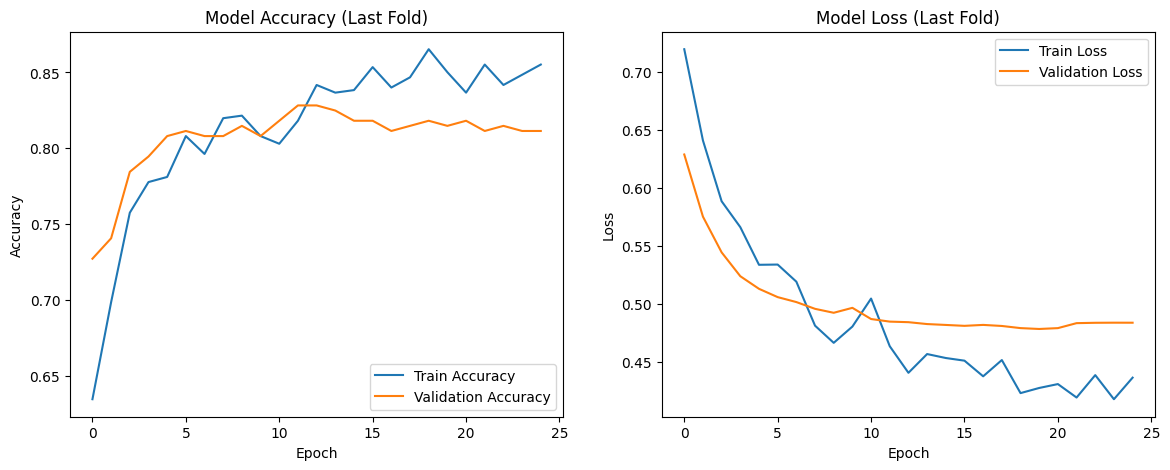

In [122]:
# Plot last fold's training history
last_hist = histories[-1]
hist_df = pd.DataFrame(last_hist)

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(hist_df['accuracy'], label='Train Accuracy')
plt.plot(hist_df['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy (Last Fold)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss
plt.subplot(1, 2, 2)
plt.plot(hist_df['loss'], label='Train Loss')
plt.plot(hist_df['val_loss'], label='Validation Loss')
plt.title('Model Loss (Last Fold)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()

####7. Prediction & Submission¶
With our model trained, it's time to predict survival on the test set.

In [123]:
# Use the trained model to predict probabilities on the scaled test data
y_pred_probs = model.predict(X_test)

# Convert probabilities to binary predictions (0 or 1)
# If the probability is 0.5 or greater, predict 1 (Survived), otherwise predict 0
y_pred = (y_pred_probs >= 0.5).astype(int).flatten() # Flatten to a 1D array

print("Sample predictions:", y_pred[:10])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Sample predictions: [0 0 0 0 0 0 1 0 1 0]


In [125]:
# Create a new DataFrame for the submission
submission = pd.DataFrame({
    'PassengerId': df_test_processed['PassengerId'], # Get PassengerId from the processed test set
    'Survived': y_pred
})

# Save the DataFrame to a CSV file, without the pandas index
#submission.to_csv('/kaggle/working/submission.csv', index=False)

#print("Submission file created successfully!")
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
